# 1 - Data Cleaning

In [75]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [2]:
usage = pd.read_csv("EV_Charging_Station_Usage.csv")

In [3]:
usage.head()

,Station_ID,City,Date,Vehicle_Type,Charging_Start_Time,Charging_End_Time,Energy_Consumed_kWh,Cost_INR,Payment_Method
0,ST001,Kolkata,2025-10-15,Car,12:14,13:57,96.2,962.0,UPI
1,ST002,Pune,2025-10-15,Bus,15:27,17:26,59.2,592.0,UPI
2,ST003,Hyderabad,2025-10-15,Car,11:29,12:08,59.8,598.0,Cash
3,ST004,Indore,2025-10-15,Bus,10:12,11:45,38.3,383.0,Cash
4,ST005,Indore,2025-10-15,Car,10:19,11:03,48.9,489.0,Card


In [4]:
print(f"Rows : {usage.shape[0]}")
print(f"Columns : {usage.shape[1]}")

Rows : 500
Columns : 9


In [8]:
usage.columns

Index(['Station_ID', 'City', 'Date', 'Vehicle_Type', 'Charging_Start_Time',
       'Charging_End_Time', 'Energy_Consumed_kWh', 'Cost_INR',
       'Payment_Method'],
      dtype='object')

In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Station_ID           500 non-null    object 
 1   City                 500 non-null    object 
 2   Date                 500 non-null    object 
 3   Vehicle_Type         500 non-null    object 
 4   Charging_Start_Time  500 non-null    object 
 5   Charging_End_Time    500 non-null    object 
 6   Energy_Consumed_kWh  500 non-null    float64
 7   Cost_INR             500 non-null    float64
 8   Payment_Method       500 non-null    object 
dtypes: float64(2), object(7)
memory usage: 35.3+ KB


In [10]:
usage.describe()

,Energy_Consumed_kWh,Cost_INR
count,500.000000,500.00000
mean,52.680400,526.80400
std,27.589008,275.89008
min,3.200000,32.00000
25%,28.650000,286.50000
50%,51.600000,516.00000
75%,76.225000,762.25000
max,99.900000,999.00000


In [11]:
usage.isnull().sum()

Station_ID             0
City                   0
Date                   0
Vehicle_Type           0
Charging_Start_Time    0
Charging_End_Time      0
Energy_Consumed_kWh    0
Cost_INR               0
Payment_Method         0
dtype: int64

In [12]:
usage.drop_duplicates(inplace=True)

In [13]:
usage.dtypes

Station_ID              object
City                    object
Date                    object
Vehicle_Type            object
Charging_Start_Time     object
Charging_End_Time       object
Energy_Consumed_kWh    float64
Cost_INR               float64
Payment_Method          object
dtype: object

In [14]:
usage["Date"] = pd.to_datetime(usage["Date"])

In [15]:
usage["Charging_Start_Time"] = pd.to_datetime(
    usage["Charging_Start_Time"],
    format="%H:%M"
)

usage["Charging_End_Time"] = pd.to_datetime(
    usage["Charging_End_Time"],
    format="%H:%M"
)

In [16]:
usage["Session_Duration_Min"] = (
    usage["Charging_End_Time"] -
    usage["Charging_Start_Time"]
).dt.total_seconds() / 60

In [17]:
usage.head()

,Station_ID,City,Date,Vehicle_Type,Charging_Start_Time,Charging_End_Time,Energy_Consumed_kWh,Cost_INR,Payment_Method,Session_Duration_Min
0,ST001,Kolkata,2025-10-15,Car,1900-01-01 12:14:00,1900-01-01 13:57:00,96.2,962.0,UPI,103.0
1,ST002,Pune,2025-10-15,Bus,1900-01-01 15:27:00,1900-01-01 17:26:00,59.2,592.0,UPI,119.0
2,ST003,Hyderabad,2025-10-15,Car,1900-01-01 11:29:00,1900-01-01 12:08:00,59.8,598.0,Cash,39.0
3,ST004,Indore,2025-10-15,Bus,1900-01-01 10:12:00,1900-01-01 11:45:00,38.3,383.0,Cash,93.0
4,ST005,Indore,2025-10-15,Car,1900-01-01 10:19:00,1900-01-01 11:03:00,48.9,489.0,Card,44.0


In [20]:
print("="*50)
print("Dataset Shape:",usage.shape)
print("="*50)

Dataset Shape: (500, 10)


In [21]:
usage.head()

,Station_ID,City,Date,Vehicle_Type,Charging_Start_Time,Charging_End_Time,Energy_Consumed_kWh,Cost_INR,Payment_Method,Session_Duration_Min
0,ST001,Kolkata,2025-10-15,Car,1900-01-01 12:14:00,1900-01-01 13:57:00,96.2,962.0,UPI,103.0
1,ST002,Pune,2025-10-15,Bus,1900-01-01 15:27:00,1900-01-01 17:26:00,59.2,592.0,UPI,119.0
2,ST003,Hyderabad,2025-10-15,Car,1900-01-01 11:29:00,1900-01-01 12:08:00,59.8,598.0,Cash,39.0
3,ST004,Indore,2025-10-15,Bus,1900-01-01 10:12:00,1900-01-01 11:45:00,38.3,383.0,Cash,93.0
4,ST005,Indore,2025-10-15,Car,1900-01-01 10:19:00,1900-01-01 11:03:00,48.9,489.0,Card,44.0


In [22]:
usage.isnull().sum().to_frame("Missing Values")

,Missing Values
Station_ID,0
City,0
Date,0
Vehicle_Type,0
Charging_Start_Time,0
Charging_End_Time,0
Energy_Consumed_kWh,0
Cost_INR,0
Payment_Method,0
Session_Duration_Min,0


### Observation

- The dataset contains no missing values.
- All records are complete and suitable for further analysis.

In [23]:
print("Duplicate Rows :",usage.duplicated().sum())

Duplicate Rows : 0


In [24]:
usage.drop_duplicates(inplace=True)

In [25]:
print("Dataset Shape :", usage.shape)

Dataset Shape : (500, 10)


### Observation

- Duplicate records were checked and removed if present.
- This ensures accurate analysis without repeated charging sessions.

In [27]:
usage.dtypes

Station_ID                      object
City                            object
Date                    datetime64[ns]
Vehicle_Type                    object
Charging_Start_Time     datetime64[ns]
Charging_End_Time       datetime64[ns]
Energy_Consumed_kWh            float64
Cost_INR                       float64
Payment_Method                  object
Session_Duration_Min           float64
dtype: object

In [28]:
usage["Date"] = pd.to_datetime(usage["Date"])

In [29]:
usage.dtypes

Station_ID                      object
City                            object
Date                    datetime64[ns]
Vehicle_Type                    object
Charging_Start_Time     datetime64[ns]
Charging_End_Time       datetime64[ns]
Energy_Consumed_kWh            float64
Cost_INR                       float64
Payment_Method                  object
Session_Duration_Min           float64
dtype: object

In [30]:
usage["Charging_Start_Time"] = pd.to_datetime(
    usage["Charging_Start_Time"],
    format="%H:%M"
)

usage["Charging_End_Time"] = pd.to_datetime(
    usage["Charging_End_Time"],
    format="%H:%M"
) 

In [31]:
usage["Session_Duration_Min"] = (
    usage["Charging_End_Time"] -
    usage["Charging_Start_Time"]
).dt.total_seconds() / 60

In [32]:
usage[[
    "Charging_Start_Time",
    "Charging_End_Time",
    "Session_Duration_Min"
]].head() 

,Charging_Start_Time,Charging_End_Time,Session_Duration_Min
0,1900-01-01 12:14:00,1900-01-01 13:57:00,103.0
1,1900-01-01 15:27:00,1900-01-01 17:26:00,119.0
2,1900-01-01 11:29:00,1900-01-01 12:08:00,39.0
3,1900-01-01 10:12:00,1900-01-01 11:45:00,93.0
4,1900-01-01 10:19:00,1900-01-01 11:03:00,44.0


### Observation

A new feature, **Session_Duration_Min**, was created to measure the charging duration for each session. This metric will help analyze customer charging behavior and station utilization.

In [33]:
usage[usage["Session_Duration_Min"] < 0]

,Station_ID,City,Date,Vehicle_Type,Charging_Start_Time,Charging_End_Time,Energy_Consumed_kWh,Cost_INR,Payment_Method,Session_Duration_Min


# 2 - Feature Engineering

In [34]:
usage["Day"] = usage["Date"].dt.day

In [35]:
usage["Month"] = usage["Date"].dt.month_name()

In [36]:
usage["Month"] = usage["Date"].dt.month_name()

In [37]:
usage["Year"] = usage["Date"].dt.year

In [38]:
usage["Day_of_Week"] = usage["Date"].dt.day_name()

In [39]:
usage["Weekend"] = usage["Day_of_Week"].isin(["Saturday", "Sunday"])

In [40]:
usage["Hour"] = usage["Charging_Start_Time"].dt.hour

In [41]:
def time_slot(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

usage["Time_Slot"] = usage["Hour"].apply(time_slot)

In [44]:
usage["Revenue_Category"] = pd.qcut(
    usage["Cost_INR"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [45]:
usage.head()

,Station_ID,City,Date,Vehicle_Type,Charging_Start_Time,Charging_End_Time,Energy_Consumed_kWh,Cost_INR,Payment_Method,Session_Duration_Min,Day,Month,Year,Day_of_Week,Weekend,Hour,Time_Slot,Revenue_Category
0,ST001,Kolkata,2025-10-15,Car,1900-01-01 12:14:00,1900-01-01 13:57:00,96.2,962.0,UPI,103.0,15,October,2025,Wednesday,False,12,Afternoon,High
1,ST002,Pune,2025-10-15,Bus,1900-01-01 15:27:00,1900-01-01 17:26:00,59.2,592.0,UPI,119.0,15,October,2025,Wednesday,False,15,Afternoon,Medium
2,ST003,Hyderabad,2025-10-15,Car,1900-01-01 11:29:00,1900-01-01 12:08:00,59.8,598.0,Cash,39.0,15,October,2025,Wednesday,False,11,Morning,Medium
3,ST004,Indore,2025-10-15,Bus,1900-01-01 10:12:00,1900-01-01 11:45:00,38.3,383.0,Cash,93.0,15,October,2025,Wednesday,False,10,Morning,Medium
4,ST005,Indore,2025-10-15,Car,1900-01-01 10:19:00,1900-01-01 11:03:00,48.9,489.0,Card,44.0,15,October,2025,Wednesday,False,10,Morning,Medium


In [46]:
usage.columns

Index(['Station_ID', 'City', 'Date', 'Vehicle_Type', 'Charging_Start_Time',
       'Charging_End_Time', 'Energy_Consumed_kWh', 'Cost_INR',
       'Payment_Method', 'Session_Duration_Min', 'Day', 'Month', 'Year',
       'Day_of_Week', 'Weekend', 'Hour', 'Time_Slot', 'Revenue_Category'],
      dtype='object')

In [47]:
usage.to_csv("EV_Charging_Station_Usage.csv",index=False)

## Feature Engineering Summary

To improve business analysis and predictive modeling, several new features were created:

- Day
- Month
- Year
- Quarter
- Day of Week
- Weekend
- Hour
- Time Slot
- Revenue Category
- Energy Category

These features help analyze charging patterns over time, compare customer behavior across different periods, and improve the performance of machine learning models.

# 3 - Exploratory Data Analysis (EDA)

#### Chart 1: Revenue Distribution

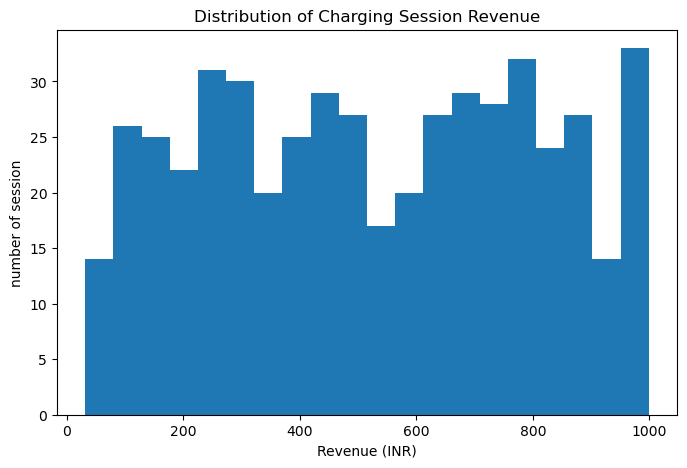

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(usage['Cost_INR'],bins=20)
plt.title("Distribution of Charging Session Revenue")
plt.xlabel('Revenue (INR)')
plt.ylabel("number of session")
plt.show()

### Business Insight

Most charging sessions fall within a moderate revenue range, indicating consistent pricing across customers. Only a small number of sessions generate very high revenue.

### Chart 2: Revenue by City

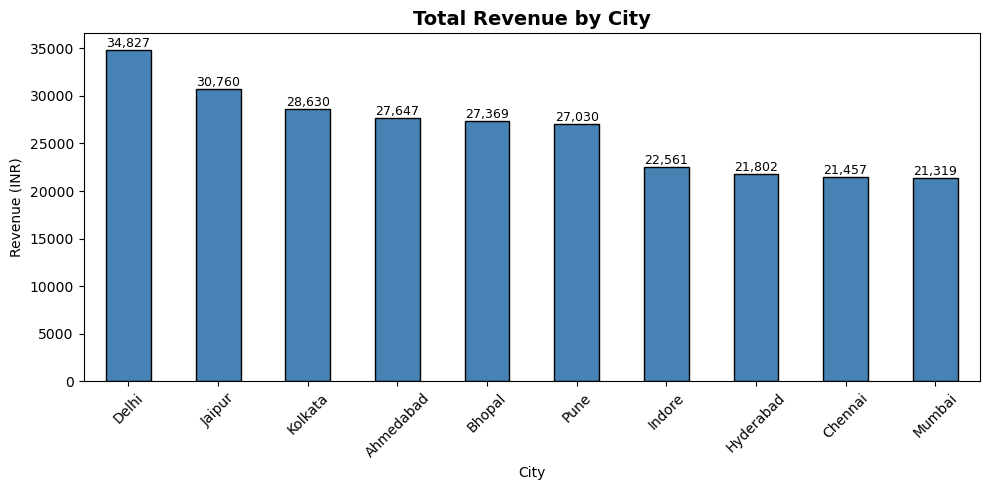

In [57]:
city_revenue = usage.groupby("City")["Cost_INR"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

ax = city_revenue.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Total Revenue by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)

# Add value labels above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=9)

plt.tight_layout()
plt.show()

### Business Insight

The chart highlights the cities contributing the highest revenue. These cities represent key markets where operators should prioritize capacity expansion and customer retention.

## Which city generated the highest revenue?

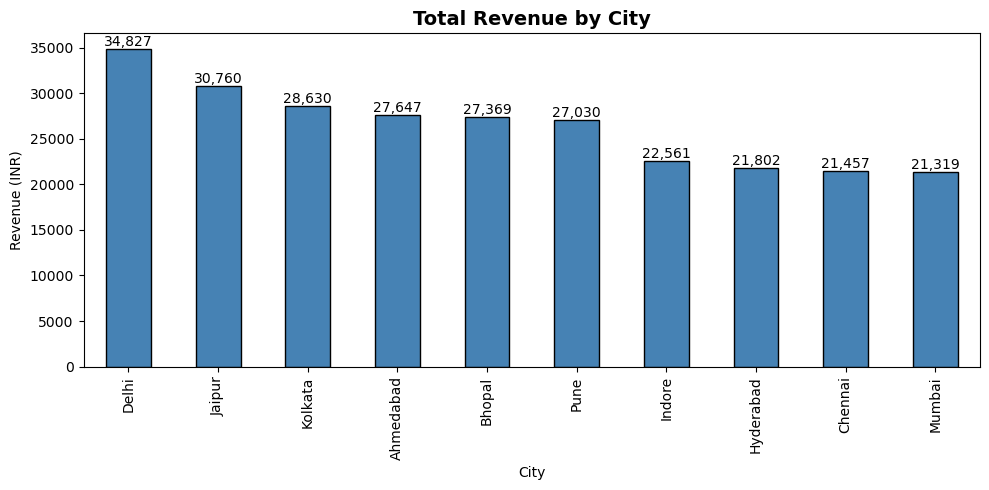

In [65]:
city_revenue = usage.groupby("City")["Cost_INR"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

ax = city_revenue.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Total Revenue by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Revenue (INR)")

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom')

plt.tight_layout()
plt.show() 

## Which city consumed the most energy?

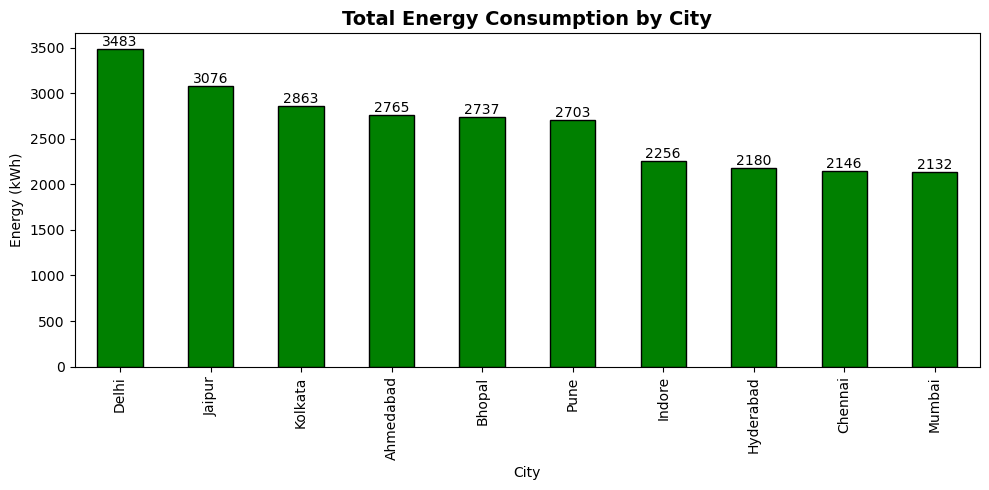

In [68]:
energy = usage.groupby("City")["Energy_Consumed_kWh"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

ax = energy.plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Total Energy Consumption by City", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Energy (kWh)")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom')

plt.tight_layout()
plt.show() 

## Which payment method is most preferred?

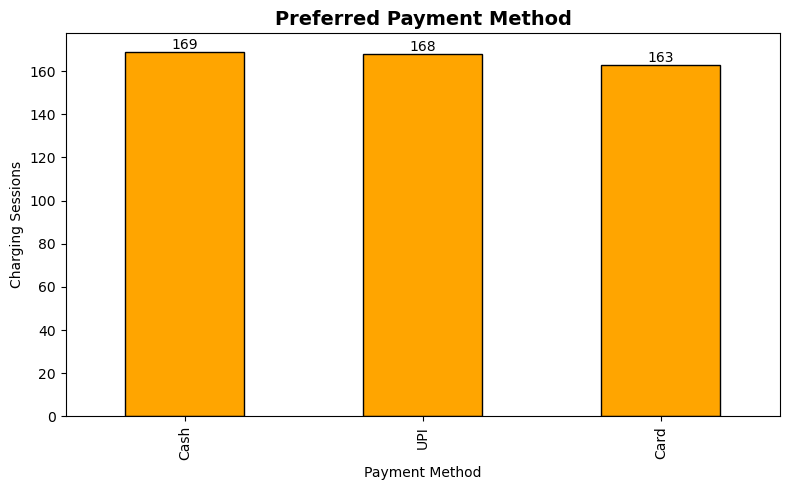

In [69]:
payment = usage["Payment_Method"].value_counts()

plt.figure(figsize=(8,5))

ax = payment.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Preferred Payment Method", fontsize=14, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Charging Sessions")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom')

plt.tight_layout()
plt.show() 

## Which vehicle type generates the highest revenue?

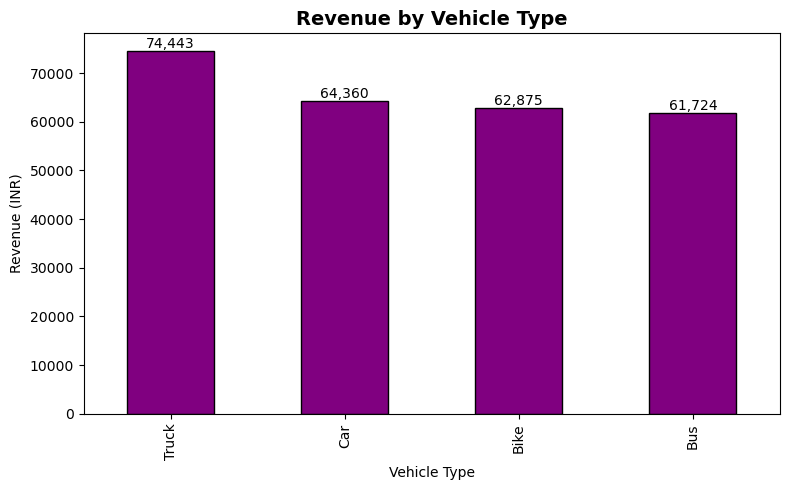

In [70]:
vehicle_rev = usage.groupby("Vehicle_Type")["Cost_INR"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = vehicle_rev.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Revenue by Vehicle Type", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Type")
plt.ylabel("Revenue (INR)")

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom')

plt.tight_layout()
plt.show() 

## What are the busiest charging hours? 

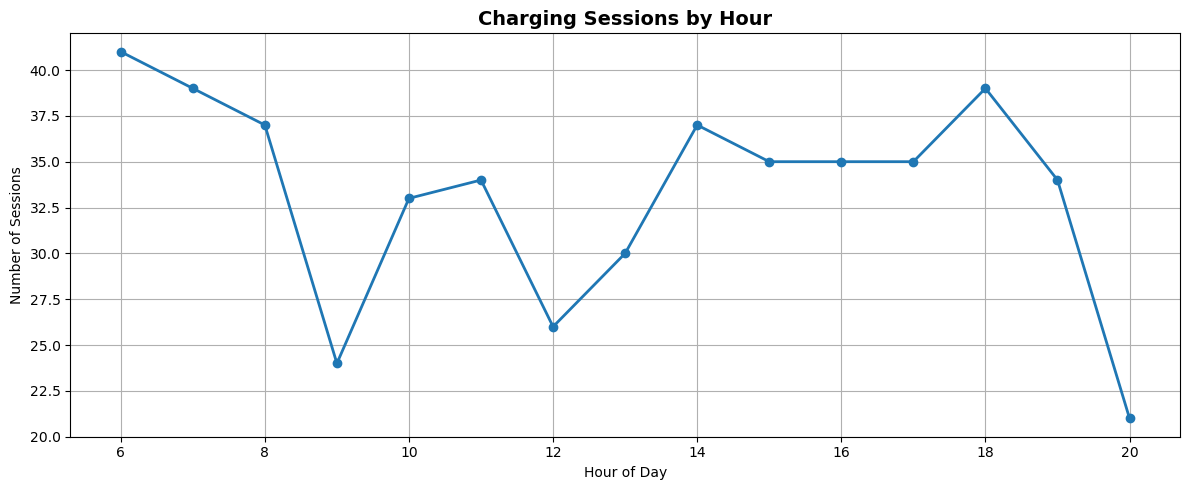

In [72]:
hour = usage["Hour"].value_counts().sort_index()

plt.figure(figsize=(12,5))

ax = hour.plot(
    kind="line",
    marker="o",
    linewidth=2
)

plt.title("Charging Sessions by Hour", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")
plt.grid(True)

plt.tight_layout()
plt.show() 

## Which time slot has the highest demand? 

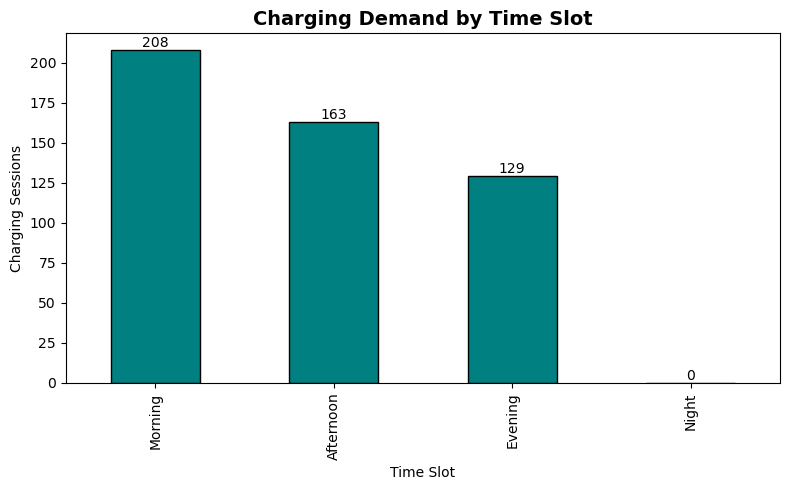

In [73]:
slot = usage["Time_Slot"].value_counts().reindex(
    ["Morning", "Afternoon", "Evening", "Night"]
)

plt.figure(figsize=(8,5))

ax = slot.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Charging Demand by Time Slot", fontsize=14, fontweight="bold")
plt.xlabel("Time Slot")
plt.ylabel("Charging Sessions")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom')

plt.tight_layout()
plt.show() 

## Does longer charging duration increase revenue?

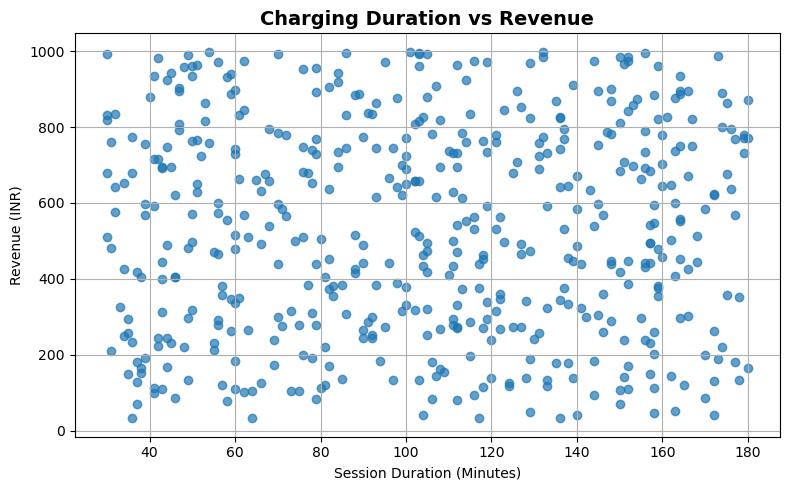

In [74]:
plt.figure(figsize=(8,5))

plt.scatter(
    usage["Session_Duration_Min"],
    usage["Cost_INR"],
    alpha=0.7
)

plt.title("Charging Duration vs Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Session Duration (Minutes)")
plt.ylabel("Revenue (INR)")

plt.grid(True)
plt.tight_layout()
plt.show() 

# 4 - statistical analysis

### Summary Statistics 

In [79]:
usage.describe().round(2)

,Date,Charging_Start_Time,Charging_End_Time,Energy_Consumed_kWh,Cost_INR,Session_Duration_Min,Day,Year,Hour
count,500,500,500,500.00,500.00,500.00,500.0,500.0,500.00
mean,2025-10-15 00:00:00,1900-01-01 13:18:00.839999744,1900-01-01 15:02:34.800000,52.68,526.80,104.57,15.0,2025.0,12.81
min,2025-10-15 00:00:00,1900-01-01 06:00:00,1900-01-01 06:53:00,3.20,32.00,30.00,15.0,2025.0,6.00
25%,2025-10-15 00:00:00,1900-01-01 09:20:15,1900-01-01 10:58:45,28.65,286.50,65.75,15.0,2025.0,9.00
50%,2025-10-15 00:00:00,1900-01-01 13:32:00,1900-01-01 14:58:30,51.60,516.00,105.00,15.0,2025.0,13.00
75%,2025-10-15 00:00:00,1900-01-01 17:13:15,1900-01-01 18:54:00,76.22,762.25,144.00,15.0,2025.0,17.00
max,2025-10-15 00:00:00,1900-01-01 20:59:00,1900-01-01 23:36:00,99.90,999.00,180.00,15.0,2025.0,20.00
std,NaN,NaN,NaN,27.59,275.89,43.41,0.0,0.0,4.35


#### The summary statistics provide an overview of charging cost, energy consumption, and session duration. These metrics help identify the overall operating range and detect potential outliers.

### Correlaton matrix

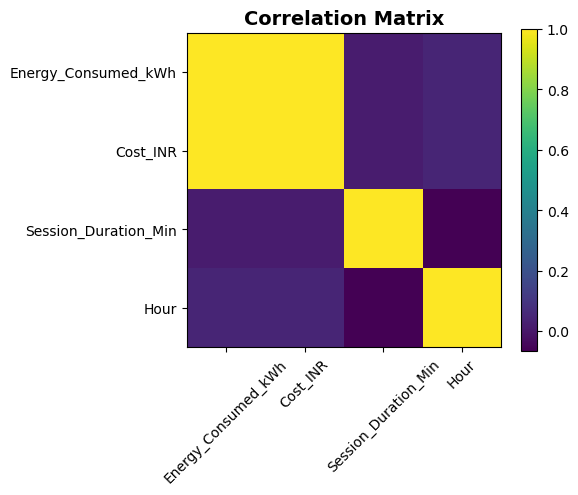

In [80]:
import matplotlib.pyplot as plt

corr = usage[[
    "Energy_Consumed_kWh",
    "Cost_INR",
    "Session_Duration_Min",
    "Hour"
]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show() 

### Pearson Correlation 

In [78]:
usage[["Energy_Consumed_kWh",
       "Cost_INR",
       "Session_Duration_Min"]].corr(method="pearson") 

,Energy_Consumed_kWh,Cost_INR,Session_Duration_Min
Energy_Consumed_kWh,1.000000,1.000000,0.017111
Cost_INR,1.000000,1.000000,0.017111
Session_Duration_Min,0.017111,0.017111,1.000000


### Vehicle type vs Revenue (ANOVA)

In [81]:
from scipy.stats import f_oneway

In [88]:
groups=[
    group["Cost_INR"].values for _,group in usage.groupby('Vehicle_Type')
]
f_stat,p_value = f_oneway(*groups)
print('F-statistic:',round(f_stat,2))
print('P-Value:',p_value)

F-statistic: 1.57
P-Value: 0.19616837161148482


In [125]:
usage.describe().round(2)

,Date,Charging_Start_Time,Charging_End_Time,Energy_Consumed_kWh,Cost_INR,Session_Duration_Min,Day,Year,Hour
count,500,500,500,500.00,500.00,500.00,500.0,500.0,500.00
mean,2025-10-15 00:00:00,1900-01-01 13:18:00.839999744,1900-01-01 15:02:34.800000,52.68,526.80,104.57,15.0,2025.0,12.81
min,2025-10-15 00:00:00,1900-01-01 06:00:00,1900-01-01 06:53:00,3.20,32.00,30.00,15.0,2025.0,6.00
25%,2025-10-15 00:00:00,1900-01-01 09:20:15,1900-01-01 10:58:45,28.65,286.50,65.75,15.0,2025.0,9.00
50%,2025-10-15 00:00:00,1900-01-01 13:32:00,1900-01-01 14:58:30,51.60,516.00,105.00,15.0,2025.0,13.00
75%,2025-10-15 00:00:00,1900-01-01 17:13:15,1900-01-01 18:54:00,76.22,762.25,144.00,15.0,2025.0,17.00
max,2025-10-15 00:00:00,1900-01-01 20:59:00,1900-01-01 23:36:00,99.90,999.00,180.00,15.0,2025.0,20.00
std,NaN,NaN,NaN,27.59,275.89,43.41,0.0,0.0,4.35


In [126]:
usage.to_csv("EV_Charging_Cleaned.csv", index=False)

In [127]:
import os

print(os.getcwd())

C:\Users\Roshi\EV_Project
